## Nonlinear Stochastic Density Steering via Gaussian Mixture Schrodinger Bridges and Multiple Linearizations



In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import annotations
import os, sys
import numpy as np
import torch
import torchsde
import ot
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
from matplotlib.patches import Ellipse
from matplotlib.ticker import MultipleLocator
from matplotlib.ticker import AutoMinorLocator
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from sklearn.mixture import GaussianMixture
from torch.distributions import Categorical, MultivariateNormal, MixtureSameFamily

_HERE = os.path.dirname(os.path.abspath("__file__"))
_ROOT = os.path.abspath(os.path.join(_HERE, os.pardir))
if _ROOT not in sys.path:
    sys.path.insert(0, _ROOT)

from src import GMMflow_SDP
from src import nominal_ref as nf

mpl.rcParams.update({
    "font.family": "serif", "font.size": 11,
    "axes.labelsize": 12, "axes.titlesize": 13,
    "legend.fontsize": 9, "xtick.labelsize": 10, "ytick.labelsize": 10,
    "figure.dpi": 150, "savefig.dpi": 300, "savefig.bbox": "tight",
    "axes.grid": True, "grid.alpha": 0.35, "grid.linestyle": ":",
    "lines.linewidth": 1.4, "text.usetex": False, "mathtext.fontset": "cm",
})

COLORS = {
    "sun": "#525151",
    "orbit": "#244797",
    "ref": "#9E461E",
    "traj_sl": "#201F1F",
    "traj_ml": "#201F1F",
    "initial": "#327A92",
    "final": "#71C2EB",
    "target": "#0C0C0C",
}

Physical Constants & Parameters

In [3]:
AU  = 149_597_870.7; DAY = 86_400.0; V = AU / DAY

n0, n1 = 3, 2
n_nodes = 101
noise_levels = [1]
n_particles = 1000
seed = 42

torch.manual_seed(seed); np.random.seed(seed)

print(f"AU={AU:.1f} km, DAY={DAY:.0f} s, V={V:.6f} km/s")
print(f"n₀={n0}, n₁={n1}, N={n_nodes}, ε=+-{noise_levels}, particles={n_particles}")

AU=149597870.7 km, DAY=86400 s, V=1731.456837 km/s
n₀=3, n₁=2, N=101, ε=+-[1], particles=1000


Define Initial & Final Mean States

In [4]:
mu0_centre = torch.tensor([-0.94052, -0.34502, 9.7746/V, -28.078/V], dtype=torch.float64)
mu1_centre = torch.tensor([-1.1543,   1.1829, -16.427/V, -14.861/V], dtype=torch.float64)

print("μ₀ (Earth):", mu0_centre.numpy())
print("μ₁ (Mars): ", mu1_centre.numpy())
print(f"|r₀|={torch.linalg.norm(mu0_centre[:2]):.5f} AU, |r₁|={torch.linalg.norm(mu1_centre[:2]):.5f} AU")

μ₀ (Earth): [-0.94052   -0.34502    0.0056453 -0.0162164]
μ₁ (Mars):  [-1.1543      1.1829     -0.00948739 -0.00858295]
|r₀|=1.00181 AU, |r₁|=1.65277 AU


Build Initial & Final GMMs

In [5]:
# Case 1: Artificially isolated peak Gaissuan to enphasize spread and multimodality
spread_pos = 0.01; spread_vel = 0.01 / V
gen_cov= torch.diag(torch.tensor([spread_pos**2]*2 + [spread_vel**2]*2, dtype=torch.float64))

Mu0 = MultivariateNormal(mu0_centre, gen_cov).sample((n0,))
Mu1 = MultivariateNormal(mu1_centre, gen_cov).sample((n1,))

Si = torch.diag(torch.tensor([4.5e-9, 4.5e-9, 3.5e-9, 3.5e-9], dtype=torch.float64))
Sf = torch.diag(torch.tensor([4.5e-6, 4.5e-6, 3.5e-8, 3.5e-8], dtype=torch.float64))

Sigma0 = Si.unsqueeze(0).expand(n0,-1,-1).clone()
Sigma1 = Sf.unsqueeze(0).expand(n1,-1,-1).clone()

W0 = torch.ones(n0, dtype=torch.float64) / n0
W1 = torch.ones(n1, dtype=torch.float64) / n1

rho0 = MixtureSameFamily(Categorical(W0), MultivariateNormal(Mu0, Sigma0))
rho1 = MixtureSameFamily(Categorical(W1), MultivariateNormal(Mu1, Sigma1))

mu0_gmm = (W0[:,None]*Mu0).sum(0)
mu1_gmm = (W1[:,None]*Mu1).sum(0)

def _gmm_covariance(w, mu, sigma, mu_gmm):
     intra = (w[:,None,None]*sigma).sum(0)
     diff = mu - mu_gmm
     inter = (w[:,None,None]*(diff.unsqueeze(2)@diff.unsqueeze(1))).sum(0)
     return intra + inter

Sigma0_gmm = _gmm_covariance(W0, Mu0, Sigma0, mu0_gmm)
Sigma1_gmm = _gmm_covariance(W1, Mu1, Sigma1, mu1_gmm)

gmm0 = MixtureSameFamily(Categorical(W0), MultivariateNormal(Mu0, Sigma0))
gmm1 = MixtureSameFamily(Categorical(W1), MultivariateNormal(Mu1, Sigma1))

print("Mu0:\n", Mu0.numpy())
print("Mu1:\n", Mu1.numpy())
print(f"W0={W0.numpy()}, W1={W1.numpy()}")
print(f"tr(Σ₀_gmm)={torch.trace(Sigma0_gmm).item():.3e}, tr(Σ₁_gmm)={torch.trace(Sigma1_gmm).item():.3e}")

Mu0:
 [[-0.9371531  -0.34373191  0.00564666 -0.01621507]
 [-0.95174856 -0.34688328  0.00565806 -0.01622009]
 [-0.93590343 -0.34234649  0.00564839 -0.01621173]]
Mu1:
 [[-1.1431971   1.16600201 -0.0094931  -0.00857741]
 [-1.14107865  1.1910719  -0.00949181 -0.00858728]]
W0=[0.33333333 0.33333333 0.33333333], W1=[0.5 0.5]
tr(Σ₀_gmm)=5.536e-05, tr(Σ₁_gmm)=1.673e-04


In [6]:
# Case 2: Large Spred Gaussian sampled and GMM fitting

# cov0 = torch.diag(torch.tensor([1e-3, 1e-3, 1e-7, 1e-7], dtype=torch.float64))
# cov1 = torch.diag(torch.tensor([1e-3, 1e-3, 1e-7, 1e-7], dtype=torch.float64))
# rho0 = MultivariateNormal(mu0_centre, cov0)
# rho1 = MultivariateNormal(mu1_centre, cov1)
# gen_samples0 = rho0.sample((10000,))
# gen_samples1 = rho1.sample((10000,))

# gmm0 = GaussianMixture(n_components = n0, covariance_type='full', random_state=seed, reg_covar=1e-10).fit(gen_samples0.numpy())
# gmm1 = GaussianMixture(n_components = n1, covariance_type='full', random_state=seed, reg_covar=1e-10).fit(gen_samples1.numpy())

# Mu0 = torch.tensor(gmm0.means_).double()
# Mu1 = torch.tensor(gmm1.means_).double()

# Sigma0 = torch.tensor(gmm0.covariances_).double()
# Sigma1 = torch.tensor(gmm1.covariances_).double()

# W0 = torch.tensor(gmm0.weights_).double()
# W1 = torch.tensor(gmm1.weights_).double()

# mu0_gmm = (W0[:,None]*Mu0).sum(0)
# mu1_gmm = (W1[:,None]*Mu1).sum(0)

# Sigma0_gmm = _gmm_covariance(W0, Mu0, Sigma0, mu0_gmm)
# Sigma1_gmm = _gmm_covariance(W1, Mu1, Sigma1, mu1_gmm)

Plot Initial Distributions

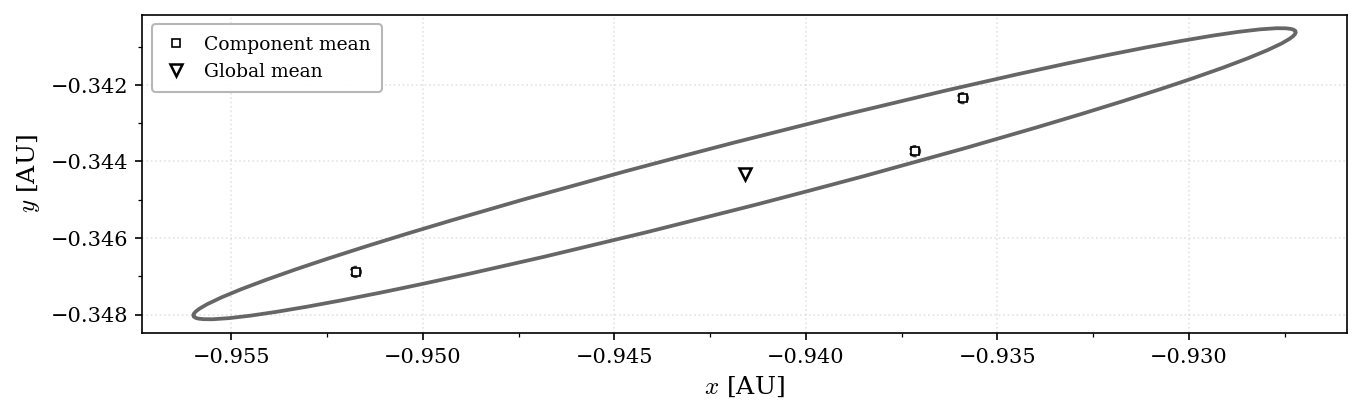

In [7]:
def confidence_ellipse_from_cov(ax, mean, cov_2x2, n_std=2.0,
                                 scale_factor=1.0, facecolor="none", **kwargs):
    cov = np.asarray(cov_2x2, dtype=float)
    std_x = np.sqrt(max(cov[0, 0], 0))
    std_y = np.sqrt(max(cov[1, 1], 0))
    if std_x < 1e-30 or std_y < 1e-30:
        return None
    pearson = np.clip(cov[0, 1] / (std_x * std_y), -1, 1)
    ell = Ellipse((0, 0),
                  width=2 * np.sqrt(1 + pearson),
                  height=2 * np.sqrt(1 - pearson),
                  facecolor=facecolor, **kwargs)
    transf = (transforms.Affine2D()
              .rotate_deg(45)
              .scale(std_x * n_std * scale_factor,
                     std_y * n_std * scale_factor)
              .translate(mean[0], mean[1]))
    ell.set_transform(transf + ax.transData)
    return ax.add_patch(ell)

fig, ax = plt.subplots(figsize=(9, 9))

for k in range(n0):
    mu_k    = Mu0[k].numpy()
    cov_sub = Sigma0[k].numpy()[np.ix_([0, 1], [0, 1])]
    ax.plot(mu_k[0], mu_k[1],
            "s", color="black", mfc="none",
            ms=4, mew=0.8, zorder=10,
            label="Component mean" if k == 0 else None)
    confidence_ellipse_from_cov(
        ax, [mu_k[0], mu_k[1]], cov_sub,
        n_std=2.0, scale_factor=1.0,
        edgecolor="black", lw=1.0, ls="--", zorder=8, alpha=0.75)

# Ellisse e media globale GMM
gmm_mu      = mu0_gmm.numpy()
gmm_cov_sub = Sigma0_gmm.numpy()[np.ix_([0, 1], [0, 1])]
ax.plot(gmm_mu[0], gmm_mu[1],
        "v", color="black", mfc="none",
        ms=6, mew=1.2, zorder=10, label="Global mean")
confidence_ellipse_from_cov(
    ax, [gmm_mu[0], gmm_mu[1]], gmm_cov_sub,
    n_std=2.0, scale_factor=1.0,
    edgecolor="#555555", lw=1.8, ls="-", zorder=9, alpha=0.9)

ax.set_xlabel(r"$x$ [AU]")
ax.set_ylabel(r"$y$ [AU]")
ax.set_aspect("equal")
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.legend(loc="best", framealpha=0.95, edgecolor="0.7",
          handlelength=1.4, borderpad=0.6)

plt.tight_layout(pad=0.4)
plt.savefig("gmm_rho0_position.pdf")

Solve Single-Linearisation (SL) Open-Loop Reference

In [8]:
print("Solving SL open-loop reference …")
ol_sl = nf.OpenLoop(mu0_gmm.numpy(), mu1_gmm.numpy(), n_nodes)
ol_sl.solve()

sl_ref, sl_uref = ol_sl.x_ref, ol_sl.u_ref
sl_Ad, sl_Bd, sl_DD = ol_sl.A_d, ol_sl.B_d, ol_sl.DD
sl_Alin, sl_Blin = ol_sl.A_lin, ol_sl.B_lin
sl_Dlin = [Dk/np.sqrt(dt) for Dk, dt in zip(ol_sl.D_d, ol_sl.dt_grid)]
sl_t, sl_dt = ol_sl.t_grid, ol_sl.dt_grid

dv = np.sum(np.linalg.norm(sl_uref, axis=1) * sl_dt)
print(f"  tf={ol_sl.tf_days:.2f} days, N={n_nodes}")
print(f"  Final pos err: {np.linalg.norm(sl_ref[:2,-1] - mu1_gmm.numpy()[:2]):.2e}")

Solving SL open-loop reference …
  tf=348.79 days, N=101
  Final pos err: 2.92e-11


Solve Multiple-Linearisation (ML) Open-Loop References

In [9]:
print("Solving ML references …")
ml_refs, ml_urefs = [], []
ml_Ad, ml_Bd, ml_DD = [], [], []
ml_Alin, ml_Blin, ml_Dlin = [], [], []
ml_t, ml_dt = [], []

for i in range(n0):
    for j in range(n1):
        print(f"  ({i},{j}) …", end=" ")
        ol = nf.OpenLoop(Mu0[i].numpy(), Mu1[j].numpy(), n_nodes)
        ol.solve()
        ml_refs.append(ol.x_ref); ml_urefs.append(ol.u_ref)
        ml_Ad.append(ol.A_d); ml_Bd.append(ol.B_d); ml_DD.append(ol.DD)
        ml_Alin.append(ol.A_lin); ml_Blin.append(ol.B_lin)
        ml_Dlin.append([Dk/np.sqrt(dt) for Dk, dt in zip(ol.D_d, ol.dt_grid)])
        ml_t.append(ol.t_grid); ml_dt.append(ol.dt_grid)
        print(f"err={np.linalg.norm(ol.x_ref[:2,-1]-Mu1[j].numpy()[:2]):.2e}")

Solving ML references …
  (0,0) … err=2.74e-10
  (0,1) … err=3.33e-10
  (1,0) … err=1.28e-10
  (1,1) … err=5.43e-10
  (2,0) … err=3.05e-10
  (2,1) … err=1.97e-10


Solve Covariance Steering (OCS via SDP)

In [10]:
results = {"SL": {}, "ML": {}}

for eps in noise_levels:
    print(f"\n── ε = {eps:.0f} ──")
    sde_sl = GMMflow_SDP(
        mu0=mu0_gmm.unsqueeze(0), mu1=mu1_gmm.unsqueeze(0),
        sigma0=Sigma0_gmm.unsqueeze(0), sigma1=Sigma1_gmm.unsqueeze(0),
        w0=torch.tensor([1.0], dtype=torch.float64),
        w1=torch.tensor([1.0], dtype=torch.float64),
        A_d=[sl_Ad], B_d=[sl_Bd], DD=[sl_DD],
        A_lin=[sl_Alin], B_lin=[sl_Blin], D_lin=[sl_Dlin],
        x_ref=[sl_ref], u_ref=[sl_uref],
        t_grid=[sl_t], dt_grid=[sl_dt],
        n_nodes=n_nodes, diffusion_scale=eps,
    )
    results["SL"][eps] = {"sde": sde_sl}
    print(f"  SL OT cost = {sde_sl.compute_ot_cost():.5e}")

    sde_ml = GMMflow_SDP(
        mu0=Mu0, mu1=Mu1, sigma0=Sigma0, sigma1=Sigma1, w0=W0, w1=W1,
        A_d=ml_Ad, B_d=ml_Bd, DD=ml_DD,
        A_lin=ml_Alin, B_lin=ml_Blin, D_lin=ml_Dlin,
        x_ref=ml_refs, u_ref=ml_urefs,
        t_grid=ml_t, dt_grid=ml_dt,
        n_nodes=n_nodes, diffusion_scale=eps,
    )
    results["ML"][eps] = {"sde": sde_ml}
    print(f"  ML OT cost = {sde_ml.compute_ot_cost():.5e}")
    print(f"  ML coupling Λ:\n{sde_ml.coupling.numpy()}")


── ε = 1 ──
  SL OT cost = 1.31501e-07
  ML OT cost = 1.29579e-07
  ML coupling Λ:
[[0.33333333 0.        ]
 [0.16666667 0.16666667]
 [0.         0.33333333]]


SDE Simulation

In [11]:
sde_dt = (sl_t[1]-sl_t[0])

for eps in noise_levels:
    print(f"SL ε={eps:.0f} …", end=" ")
    sde_sl = results["SL"][eps]["sde"]
    y0_sl = rho0.sample((n_particles,))
    t_sl = torch.tensor(sl_t, dtype=torch.float64)
    t_sde = torch.linspace( t_sl[0], t_sl[-1], int((t_sl[-1] - t_sl[0])/sde_dt+1))
    results["SL"][eps]["y"] = torchsde.sdeint(sde_sl, y0_sl, t_sde, method="euler", dt=sde_dt)
    
    sde_ml = results["ML"][eps]["sde"]
    y0_ml = rho0.sample((n_particles,))
    t_ml = torch.tensor(ml_t[0], dtype=torch.float64)
    results["ML"][eps]["y"] = torchsde.sdeint(sde_ml, y0_ml, t_sde, method="euler", dt=sde_dt)

SL ε=1 … 

Plot Trajectory Comparison (SL - ML)

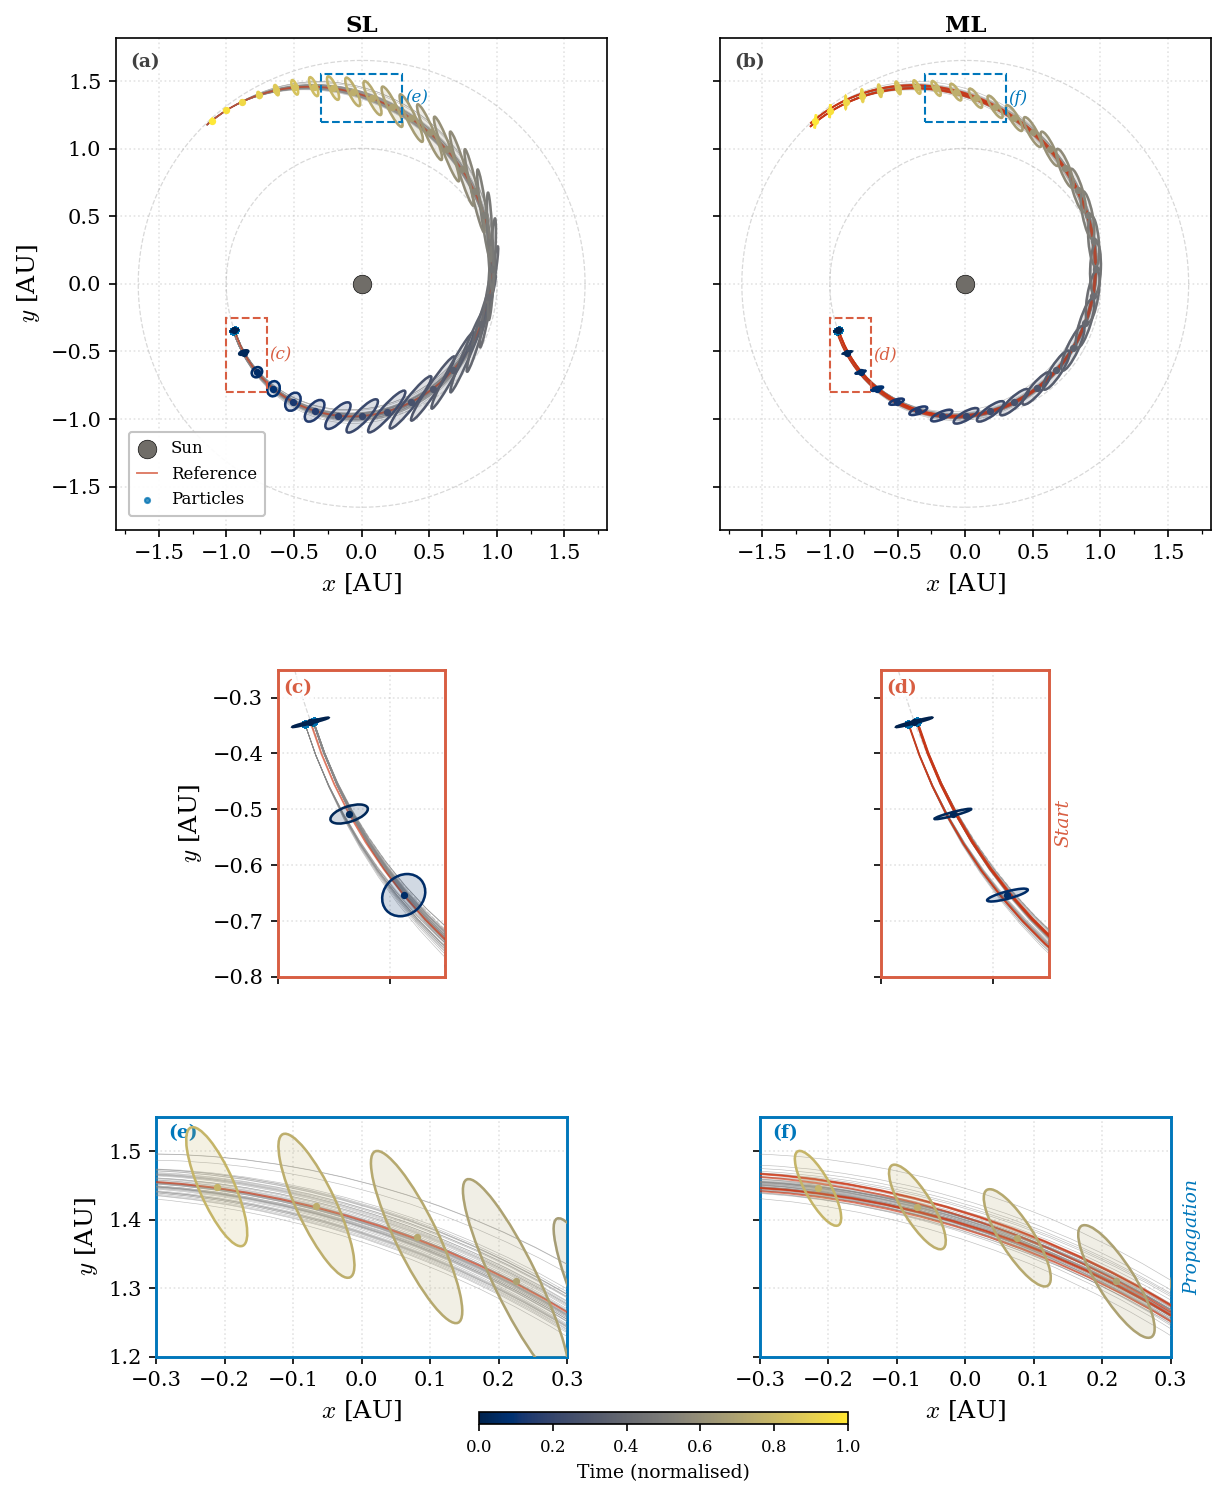

In [ ]:
COLORS = {
    "orbit":   "#AAAAAA",
    "sun":     "#706D68",
    "initial": "#0072B2",
}
REF_COLOR   = "#CC3311"
TRAJ_COLOR  = "#888888"
ELLIPSE_CMAP = plt.cm.cividis
ELLIPSE_SCALE = 1.0

target_samples = rho1.sample((n_particles,))
n_show = 50
snap_indices = np.arange(0, n_nodes, 3)
eps = noise_levels[0]

ZOOM1 = dict(x0=-1.0,  x1=-0.70, y0=-0.8, y1=-0.25)   # start region
ZOOM2 = dict(x0=-0.30, x1= 0.30, y0= 1.20, y1= 1.55)   # propagation region
ZOOM_COLORS = ["#D85E42", "#0077BB"]

# Filled 3-sigma ellipse
def filled_confidence_ellipse(ax, mean, cov, n_std=3.0, scale_factor=1.0,
                               facecolor="C0", edgecolor="C0",
                               alpha_face=0.1, lw=1.2, zorder=5):
    vals, vecs = np.linalg.eigh(cov)
    vals = np.maximum(vals, 0.0)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 3 * n_std * scale_factor * np.sqrt(vals)
    ellipse = Ellipse(
        xy=mean, width=width, height=height, angle=angle,
        facecolor=facecolor, edgecolor=edgecolor,
        alpha=alpha_face, linewidth=lw, zorder=zorder
    )
    edge = Ellipse(
        xy=mean, width=width, height=height, angle=angle,
        facecolor="none", edgecolor=edgecolor,
        linewidth=lw, zorder=zorder + 0.1
    )
    ax.add_patch(ellipse)
    ax.add_patch(edge)

def plot_on(ax, mode, eps, show_ylabel=True, show_xlabel=True,
            xlim=None, ylim=None):
    y = results[mode][eps]["y"]

    # Orbit rings
    r_earth = np.sqrt(float(mu0_centre[0])**2 + float(mu0_centre[1])**2)
    r_mars = np.sqrt(float(mu1_centre[0])**2 + float(mu1_centre[1])**2)
    theta = np.linspace(0, 2*np.pi, 200)
    ax.plot(r_earth * np.cos(theta), r_earth * np.sin(theta),
            "--", color=COLORS["orbit"], lw=0.6, alpha=0.45)
    ax.plot(r_mars  * np.cos(theta), r_mars  * np.sin(theta),
            "--", color=COLORS["orbit"], lw=0.6, alpha=0.45)

    # Sun
    ax.scatter(0, 0, s=80, color=COLORS["sun"],
               edgecolors="k", linewidths=0.3, zorder=10, label="Sun")

    # Reference trajectory
    refs = [sl_ref] if mode == "SL" else ml_refs
    for k, ref in enumerate(refs):
        ax.plot(ref[0], ref[1], '-', color=REF_COLOR, lw=0.9, alpha=0.65,
                zorder=5, label="Reference" if k == 0 else None)

    # Sample trajectories
    for k in range(n_show):
        ax.plot(y[:, k, 0].numpy(), y[:, k, 1].numpy(),
                '-', color=TRAJ_COLOR, lw=0.3, alpha=0.55, zorder=3)

    # Initial scatter
    ax.scatter(y[0, :, 0].numpy(), y[0, :, 1].numpy(),
               s=6, color=COLORS["initial"], zorder=6, alpha=0.75,
               label="Particles" if show_ylabel else None)

    n_snaps = len(snap_indices)
    for si, k in enumerate(snap_indices):
        color = ELLIPSE_CMAP(si / max(n_snaps - 1, 1))
        mu_k  = np.mean(y[k].numpy(), axis=0)
        cov_k = np.cov(y[k].numpy().T)
        filled_confidence_ellipse(
            ax, mu_k[:2], cov_k[:2, :2],
            n_std=3.0, scale_factor=ELLIPSE_SCALE,
            facecolor=color, edgecolor=color,
            alpha_face=0.18, lw=1.2, zorder=6
        )
        ax.plot(mu_k[0], mu_k[1], "o", color=color, ms=2.5, zorder=7)

    ax.set_aspect("equal")
    if xlim: ax.set_xlim(*xlim)
    if ylim: ax.set_ylim(*ylim)

    if show_ylabel:
        ax.set_ylabel(r"$y$ [AU]")
    else:
        ax.set_yticklabels([])

    if show_xlabel:
        ax.set_xlabel(r"$x$ [AU]")
    else:
        ax.set_xticklabels([])

    return ax

fig = plt.figure(figsize=(10, 12))
gs = gridspec.GridSpec(
    3, 2, figure=fig,
    hspace=0.38, wspace=0.08,
    height_ratios=[1.6, 1, 1]
)

axes = [[fig.add_subplot(gs[r, c]) for c in range(2)] for r in range(3)]
PANEL_LABELS = [["(a)", "(b)"],
                ["(c)", "(d)"],
                ["(e)", "(f)"]]
ZOOM_ROW_COLORS = [None, ZOOM_COLORS[0], ZOOM_COLORS[1]]

for col, mode in enumerate(("SL", "ML")):
    show_y = (col == 0)

    plot_on(axes[0][col], mode, eps,
            show_ylabel=show_y, show_xlabel=True)
    axes[0][col].xaxis.set_major_locator(MultipleLocator(0.5))
    axes[0][col].xaxis.set_minor_locator(AutoMinorLocator(2))

    plot_on(axes[1][col], mode, eps,
            show_ylabel=show_y, show_xlabel=False,
            xlim=(ZOOM1["x0"], ZOOM1["x1"]),
            ylim=(ZOOM1["y0"], ZOOM1["y1"]))

    plot_on(axes[2][col], mode, eps,
            show_ylabel=show_y, show_xlabel=True,
            xlim=(ZOOM2["x0"], ZOOM2["x1"]),
            ylim=(ZOOM2["y0"], ZOOM2["y1"]))

    for bbox, color, letter_pair in [
        (ZOOM1, ZOOM_COLORS[0], ("(c)", "(d)")),
        (ZOOM2, ZOOM_COLORS[1], ("(e)", "(f)")),
    ]:
        rect = mpatches.FancyBboxPatch(
            (bbox["x0"], bbox["y0"]),
            bbox["x1"] - bbox["x0"],
            bbox["y1"] - bbox["y0"],
            boxstyle="square,pad=0", lw=1.0,
            edgecolor=color, facecolor="none",
            zorder=10, linestyle="--"
        )
        axes[0][col].add_patch(rect)
        lbl = letter_pair[col]
        axes[0][col].text(
            bbox["x1"] + 0.02, 0.5 * (bbox["y0"] + bbox["y1"]),
            lbl, fontsize=8, color=color,
            ha="left", va="center", style="italic",
            transform=axes[0][col].transData
        )

for row in range(3):
    for col in range(2):
        ax = axes[row][col]
        color = ZOOM_ROW_COLORS[row] if ZOOM_ROW_COLORS[row] else "0.25"
        if row > 0:
            for spine in ax.spines.values():
                spine.set_edgecolor(ZOOM_ROW_COLORS[row])
                spine.set_linewidth(1.4)
        ax.text(
            0.03, 0.97, PANEL_LABELS[row][col],
            transform=ax.transAxes,
            ha="left", va="top", fontsize=9,
            fontweight="bold", color=color,
            bbox=dict(facecolor="white", edgecolor="none",
                      alpha=0.75, pad=1.0)
        )

for col, mode in enumerate(("SL", "ML")):
    axes[0][col].set_title(mode, fontsize=11, fontweight="bold", pad=3)

row_labels = ["", "Start", "Propagation"]
for row, label in enumerate(row_labels):
    if label:
        axes[row][1].annotate(
            label, xy=(1.03, 0.5), xycoords="axes fraction",
            ha="left", va="center", fontsize=9,
            color=ZOOM_ROW_COLORS[row], style="italic",
            rotation=90
        )

axes[0][0].legend(
    loc="lower left",
    bbox_to_anchor=(0.01, 0.01),
    framealpha=0.92, edgecolor="0.75",
    fontsize=8, handlelength=1.2,
    borderpad=0.5
)

sm = plt.cm.ScalarMappable(cmap=ELLIPSE_CMAP,
                            norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=axes[2], orientation="horizontal",
                    fraction=0.04, pad=0.18, aspect=30)
cbar.set_label("Time (normalised)", fontsize=9)
cbar.ax.tick_params(labelsize=8)

plt.savefig("trajectory_comparison.pdf", bbox_inches="tight", dpi=300)
plt.show()

Final Distribution: Empirical vs Target

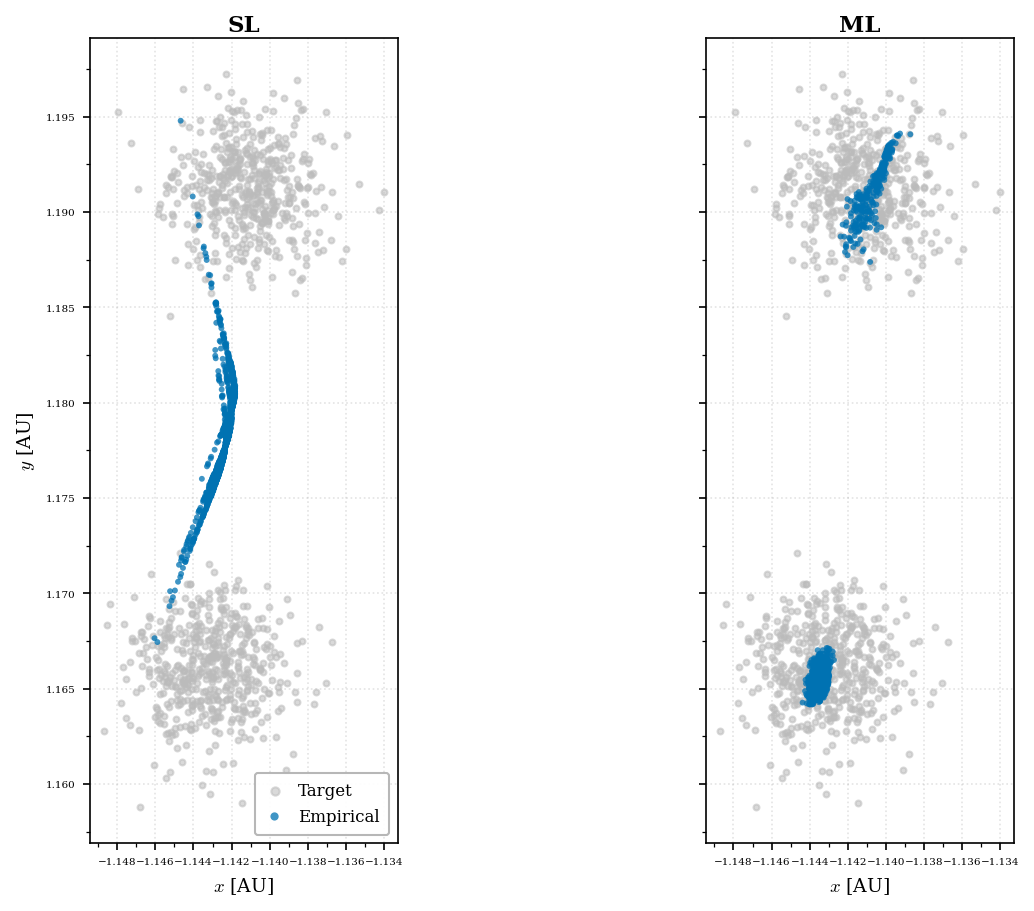

In [13]:
COLOR_TARGET     = "#BBBBBB"
COLOR_EMPIRICAL  = "#0072B2"

target_pts = rho1.sample((1000,)).numpy()
n_noise    = len(noise_levels)

fig, axes = plt.subplots(
    nrows=n_noise, ncols=2,
    sharex=True, sharey=True,
    figsize=(10, 6 * n_noise),
    squeeze=False,
)

for row, eps in enumerate(noise_levels):
    for col, mode in enumerate(("SL", "ML")):
        ax  = axes[row, col]
        emp = results[mode][eps]["y"][-1].detach().numpy()

        # Target
        ax.scatter(target_pts[:, 0], target_pts[:, 1],
                   s=8, color=COLOR_TARGET, alpha=0.55,
                   zorder=4, label="Target", rasterized=True)

        # Empirical final distribution
        ax.scatter(emp[:, 0], emp[:, 1],
                   s=8, color=COLOR_EMPIRICAL, alpha=0.75,
                   edgecolors="none",
                   zorder=5, label="Empirical", rasterized=True)

        ax.set_aspect("equal")

        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        
        ax.tick_params(axis="both", which="major", labelsize=5)

        if col == 0:
            ax.set_ylabel(r"$y$ [AU]", fontsize=9)
        if row == n_noise - 1:
            ax.set_xlabel(r"$x$ [AU]", fontsize=9)

        title = mode
        if n_noise > 1:
            title += rf"  ($\varepsilon = {eps}$)"
        ax.set_title(title, fontsize=11, fontweight="bold", pad=3)

        if row == 0 and col == 0:
            ax.legend(loc="best",
                      framealpha=0.95, edgecolor="0.7",
                      fontsize=8, handlelength=1.2, markerscale=1.4,
                      borderpad=0.6)

fig.align_ylabels(axes[:, 0])
plt.tight_layout(pad=0.4, w_pad=0.3, h_pad=0.4)
plt.savefig("final_distribution_comparison.pdf", bbox_inches="tight", dpi=300)

Quantitative Metrics

In [14]:
def wasserstein2(x, y):
    cost = torch.cdist(x.float(), y.float(), p=2)**2
    a, b = torch.ones(x.shape[0])/x.shape[0], torch.ones(y.shape[0])/y.shape[0]
    return float(torch.sqrt(torch.sum(ot.emd(a, b, cost) * cost)))

target_mean = mu1_gmm.numpy()
target_trace = torch.trace(Sigma1_gmm).item()

print("\n"+"="*90)
print(f"{'Mode':<5} {'ε':>6}  {'‖Δμ_1‖':>10}  {'tr(Σ_emp)':>11}  {'tr(Σ_target)':>11}  {'J_ctrl':>10}  {'W₂':>10} {'Sliced W₂':>10}")
print("-"*90)
for mode in ("SL","ML"):
    for eps in noise_levels:
        yf = results[mode][eps]["y"][-1].detach()
        sde = results[mode][eps]["sde"]
        em, ec = yf.mean(0).numpy(), torch.cov(yf.T)
        me = float(np.linalg.norm(em - target_mean))
        et = torch.trace(ec).item()
        jc = sde.estimate_control_cost(n_samples=500)
        w2 = wasserstein2(yf, rho1.sample((yf.shape[0],)).detach())
        sw2 = float(ot.sliced_wasserstein_distance(yf.float(), rho1.sample((10*yf.shape[0],)).float(), n_projections=100))
        print(f"{mode:<5} {eps:>6.0f}  {me:>10.3e}  {et:>11.3e}  {target_trace:>11.3e}  {jc:>10.5e}  {w2:>10.5e} {sw2:>10.5e}")
print("="*90)


Mode       ε      ‖Δμ_1‖    tr(Σ_emp)  tr(Σ_target)      J_ctrl          W₂  Sliced W₂
------------------------------------------------------------------------------------------
SL         1   3.674e-04    9.699e-06    1.673e-04  1.80433e-07  1.04175e-02 5.06921e-03
ML         1   5.940e-03    1.329e-04    1.673e-04  1.64991e-07  1.06205e-02 5.59974e-03
